##### Author: Jimin Kim (jk55@uw.edu)
##### Version 1.7.0


# Lab 2 Report

### Group Members: Richard Nadolny & Kavin Sundar

In [1]:
import numpy as np

In [2]:
from IPython.display import Image #For displaying images in colab jupyter cell

# Exercise 1: Loops vs Numpy operations

In [3]:
Image('lab2_exercise1.PNG', width = 1000)

FileNotFoundError: No such file or directory: 'lab2_exercise1.PNG'

FileNotFoundError: No such file or directory: 'lab2_exercise1.PNG'

<IPython.core.display.Image object>

In [4]:
import time # Import time to measure computational efficiency of the code

In [5]:
arr2d_1 = np.random.randn(1000, 1000) * 10
arr2d_2 = np.random.randn(1000, 1000) * 10

In [6]:
# Elementwise addition using loop

arr2d_3_loop = np.zeros((1000, 1000)) # Create a placeholder array for arr2d_3

start_time_loop = time.time() # start time of the code

# YOUR CODE HERE FOR ELEMENTWISE ADDITION USING TWO NESTED LOOPS
# Loops to iterate through rows and columns of each array, adding the individual cells of arr1 and arr2 to assign to arr3

for i in range (0,1000):
    for j in range (0,1000):
        arr2d_3_loop[i,j] = arr2d_1[i,j] + arr2d_2[i,j] 

end_time_loop = time.time() # end time of the code

elapsed_time_loop = end_time_loop - start_time_loop # end time - start time -> elapsed time in seconds
print(elapsed_time_loop)

1.1500306129455566


In [7]:
# Elementwise addition using Numpy function

start_time_np = time.time()

arr2d_3_np = np.add(arr2d_1,arr2d_2) # numpy operator for array addition

end_time_np = time.time()

elapsed_time_np = end_time_np - start_time_np
print(elapsed_time_np)

0.0055179595947265625


In [8]:
# Make sure two outputs are equivalent

np.sum(arr2d_3_loop == arr2d_3_np) == 1000 * 1000 # Should output True if the outputs are same

np.True_

### Which computation is faster and by what factor?
### e.g. a code that takes 0.1s is faster by a factor of 10 compared to a code that takes 1s

In [9]:
# the numpy function computes the array faster by a factor of nearly 1000

# Exercise 2: Generate Triangular Waveform

In [10]:
Image('lab2_exercise2.PNG', width = 1000)

FileNotFoundError: No such file or directory: 'lab2_exercise2.PNG'

FileNotFoundError: No such file or directory: 'lab2_exercise2.PNG'

<IPython.core.display.Image object>

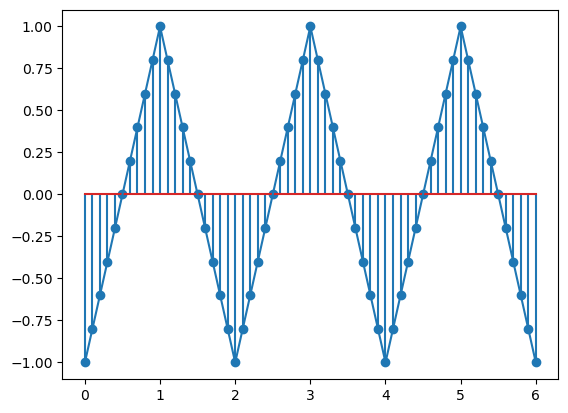

In [11]:
import matplotlib.pyplot as plt

# Defining variables to spec
amplitude = 1
frequency = 0.5
samplingFrequency = 10
period = 1/frequency

# Generate x Values array
xVals = np.arange(0,6 + 1/samplingFrequency,1/samplingFrequency) 

yVals = (np.pi * xVals) - (np.pi/2) # Convert y values to radians relative to x values, shift to start at minimum
yVals = (2/np.pi) * np.arcsin(np.sin(yVals)) # Generate y values triangle via identity and scale to amplitude 1 
plt.stem(xVals,yVals)
plt.plot(xVals,yVals)

# Exercise 3: Sinusoidal Generator

In [12]:
Image('lab2_exercise3.PNG', width = 1000)

FileNotFoundError: No such file or directory: 'lab2_exercise3.PNG'

FileNotFoundError: No such file or directory: 'lab2_exercise3.PNG'

<IPython.core.display.Image object>

In [13]:
# Define generate_sine function

# a function that returns array of time/x values and an array of amplitude/y values
# for specified time and frequency
def generate_sine(t_duration, f0, fs):
    
    # YOUR CODE HERE

    f0Radians = 2*np.pi * f0 # Convert f0 to radians
    t_arr = np.arange(0,t_duration + 1/fs, 1/fs) # Generate time array or xVals
    amplitudes = np.sin(f0Radians * t_arr) # Generate amplitude or yVals
    # Return 1D numpy arrays each containing timepoints and sine waveform amplitudes
    return t_arr, amplitudes 

In [14]:
# parameter set 1
t_duration_1 = 5
f0_1 = 0.5
fs_1 = 100
t_arr_1, amplitudes_1 = generate_sine(t_duration_1, f0_1, fs_1)

# parameter set 2
t_duration_2 = 5
f0_2 = 1.
fs_2 = 100
t_arr_2, amplitudes_2 = generate_sine(t_duration_2, f0_2, fs_2)

# parameter set 3
t_duration_3 = 5
f0_3 = 1.5
fs_3 = 100
t_arr_3, amplitudes_3 = generate_sine(t_duration_3, f0_3, fs_3)

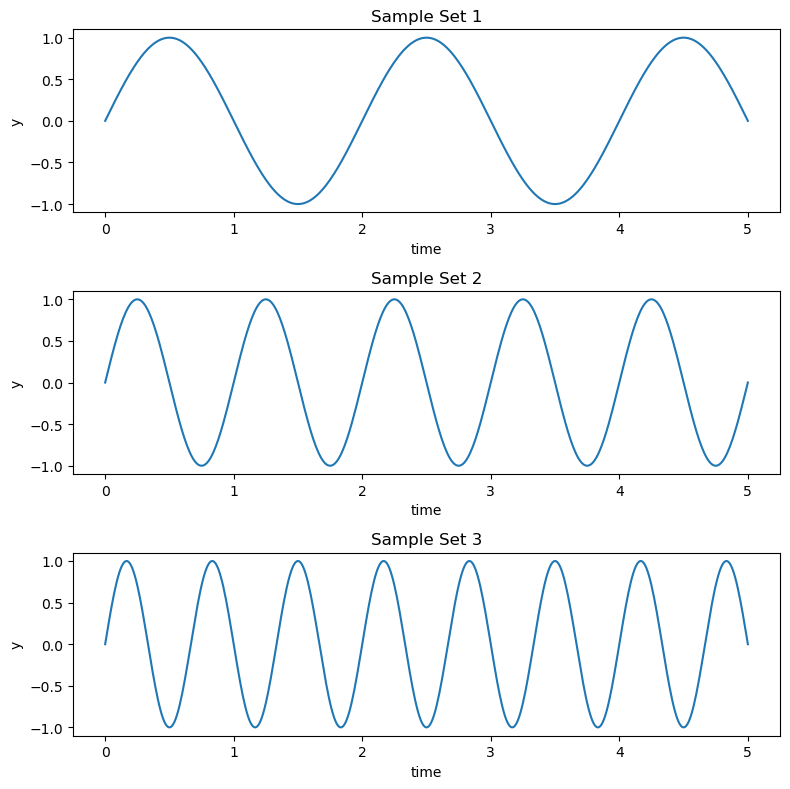

In [15]:
# Plot 3 x 1 subplot showing all three waveform

# YOUR CODE HERE

fig = plt.figure(2,figsize=(8,8)) # Define size of graph figures

plt.subplot(311) # 3x1 sublot, graph 1
plt.plot(t_arr_1, amplitudes_1)
plt.title('Sample Set 1')
plt.xlabel('time')
plt.ylabel('y')

plt.subplot(312) # 3x1 sublot, graph 2
plt.plot(t_arr_2, amplitudes_2)
plt.title('Sample Set 2')
plt.xlabel('time')
plt.ylabel('y')

plt.subplot(313) # 3x1 sublot, graph 3
plt.plot(t_arr_3, amplitudes_3)
plt.title('Sample Set 3')
plt.xlabel('time')
plt.ylabel('y')

fig.tight_layout()

# Exercise 4: Notes Synthesis

In [16]:
Image('lab2_exercise4.PNG', width = 1000)

FileNotFoundError: No such file or directory: 'lab2_exercise4.PNG'

FileNotFoundError: No such file or directory: 'lab2_exercise4.PNG'

<IPython.core.display.Image object>

In [17]:
# YOUR CODE HERE
import IPython.display as ipd
from scipy.io import wavfile as wav

# generate sine waveform of each note frequency
t, lowAWave = generate_sine(1, 220, 8000)
t, bWave = aWave = generate_sine(1, 220 * (2**(2/12)), 8000)
t, csWave = generate_sine(1, 220*(2**(4/12)), 8000)
t, dWave = generate_sine(1, 220*(2**(5/12)), 8000)
t, eWave = generate_sine(1, 220*(2**(7/12)), 8000)
t, fsWave = generate_sine(1, 220*(2**(9/12)), 8000)
t, gsWave = generate_sine(1, 220*(2**(11/12)), 8000)
t, highAWave = generate_sine(1, 440, 8000)

# merge notes into scale, convert to .wav file
a_major_scale = ((np.concatenate([lowAWave, bWave, csWave, dWave, eWave, fsWave, gsWave, highAWave]))*32767).astype(np.int16)
wav.write('a_major_scale.wav', 8000, a_major_scale)
ipd.Audio('a_major_scale.wav') # display audio



In [18]:
# NOTE: Multiply your concatenated notes (with amplitude of 1) with 32767 followed by conversion to int16 format
# before playing or writing your audio array into a file. 

# Exercise 5: Chord Synthesis

In [19]:
Image('lab2_exercise5.PNG', width = 1000)

FileNotFoundError: No such file or directory: 'lab2_exercise5.PNG'

FileNotFoundError: No such file or directory: 'lab2_exercise5.PNG'

<IPython.core.display.Image object>

In [20]:
# YOUR CODE HERE

# generate sine waveform of each note/frequency
t, lowAWave = generate_sine(1, 220, 8000)
t, bWave = aWave = generate_sine(1, 220 * (2**(2/12)), 8000)
t, csWave = generate_sine(1, 220*(2**(4/12)), 8000)
t, dWave = generate_sine(1, 220*(2**(5/12)), 8000)
t, eWave = generate_sine(1, 220*(2**(7/12)), 8000)
t, fsWave = generate_sine(1, 220*(2**(9/12)), 8000)
t, gsWave = generate_sine(1, 220*(2**(11/12)), 8000)
t, highAWave = generate_sine(1, 440, 8000)

# join specified notes into chords
chord1 = np.add(lowAWave, csWave)
chord2 = np.add(bWave,dWave)
chord3 = np.add(csWave, eWave)
chord4 = np.add(dWave, fsWave)
chord5 = np.add(eWave, gsWave)
chord6 = np.add(fsWave, highAWave)

# merge chords into scale
chords = np.concatenate([chord1, chord2, chord3, chord4, chord5, chord6])
maxAmplitude = np.max(np.abs(chords))
chords = (chords / maxAmplitude * 32767).astype(np.int16)

# convert to .wav and display
wav.write('6_chords.wav', 8000, chords)
ipd.Audio('6_chords.wav')



In [ ]:
# NOTE: Multiply your concatenated notes (with amplitude of 1) with 32767 followed by conversion to int16 format
# before playing or writing your audio array into a file. 